# 34: the literature trajectories and GSDC

Two standard maneuvering-target benchmarks with exact analytic ground truth
(a coordinated turn, a figure-8), then two real Google Smartphone Decimeter
Challenge (GSDC 2022) trips with RTK ground truth: a clean highway drive and
a downtown urban canyon. Both give a real position error, not the held-out
fix proxy the no-RTK rig is limited to. Claims:

1. Run at the sim's native scale (10.0 Hz, fix noise 1.50 m per axis, a
   median 12.0 m/s on the turn and 14.7 m/s on the figure-8), every
   tracker's clean RMSE sits within a factor of 2 of the fix noise on both
   trajectories. False if any tracker's clean RMSE falls outside
   [0.75, 3.0] m.
2. Over 30 seeds, Kalman-CA and IMM beat every dtfit route on dropout
   coasting, on both trajectories; the reweighted dtfit fit and a
   Huber-hardened Kalman are within a factor of 2 of each other under a
   multipath glitch, neither ahead by a clear margin. False if the best
   dtfit route's dropout RMSE undercuts Kalman-CA or IMM on either
   trajectory, or if the two robust glitch numbers differ by more than 2x
   on either trajectory.
3. On the GSDC highway trip, clean 1.00 Hz GPS with little multipath, every
   unhardened method and the plain dtfit route sit within 2 m of the raw
   fix at every window swept; the reweighted dtfit route is worse than the
   plain fit at every window (5.48 m at window 12, 7.72 m at 8) and blows
   up to 57.93 m at window 6. On the urban-canyon trip, the raw
   fix carries samples hundreds of metres off, and only the reweighted
   dtfit fit and the Huber-hardened Kalman bring it back under 11 m at
   every window, both single-digit at the shortest window. False if any
   unhardened highway method or the plain dtfit route strays more than 2 m
   from the raw fix at any window, or if the reweighted route's window-6
   RMSE drops under 10 m, or if the urban reweighted or Huber-hardened RMSE
   exceeds 11 m at any window.

In [1]:
import inspect
import os
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from dtfit_experimental.study import gps_benchmark as B
from dtfit_experimental.study import notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

SEEDS = range(4) if QUICK else range(30)
WINDOWS = [8] if QUICK else [6, 8, 12]
print(f"QUICK={QUICK} seeds={len(SEEDS)} windows={WINDOWS}")


QUICK=False seeds=30 windows=[6, 8, 12]


## The trajectories

`B.ct_benchmark` runs the sim's canonical coordinated-turn maneuver plan
through the identical `build_rig`/`dtfit_track` machinery the random-plan
batch uses; `B.figure8_benchmark` is a smooth Gerono lemniscate with no
turning segments at all. Both hold the truth in closed form, so every
score below is against the true path rather than a proxy.


coordinated turn: 600 samples at 10.0 Hz, fix noise 1.50 m per axis, median speed 12.0 m/s (range 12.0 to 12.0 m/s)
figure-8: 600 samples at 10.0 Hz, fix noise 1.50 m per axis, median speed 14.7 m/s (range 10.4 to 22.2 m/s)


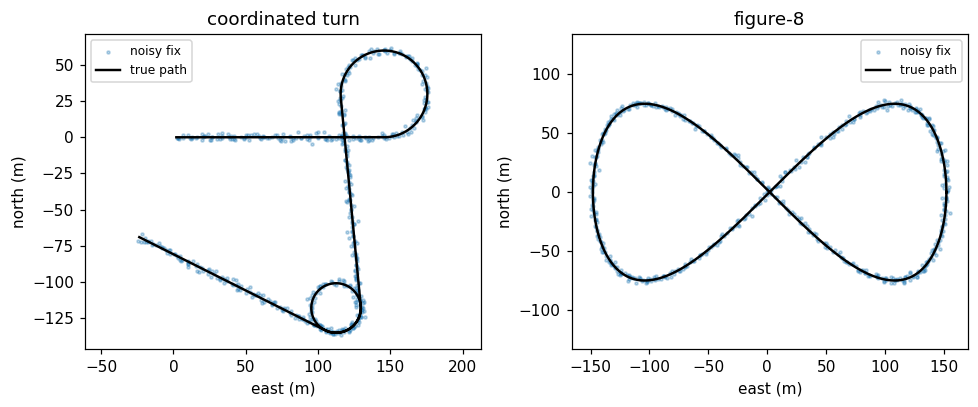

In [2]:
t_ct, truth_ct, meas_ct, lab_ct = B.ct_benchmark(seed=0)
t_f8, truth_f8, meas_f8, _ = B.figure8_benchmark(seed=0)

for title, t, truth, meas in (("coordinated turn", t_ct, truth_ct, meas_ct),
                              ("figure-8", t_f8, truth_f8, meas_f8)):
    dt = float(np.median(np.diff(t)))
    speed = np.linalg.norm(np.diff(truth, axis=0), axis=1) / np.diff(t)
    print(f"{title}: {len(t)} samples at {1.0 / dt:.1f} Hz, fix noise "
          f"{(meas - truth).std():.2f} m per axis, median speed "
          f"{np.median(speed):.1f} m/s (range {speed.min():.1f} to "
          f"{speed.max():.1f} m/s)")

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.8))
for a, truth, meas, title in ((ax[0], truth_ct, meas_ct, "coordinated turn"),
                              (ax[1], truth_f8, meas_f8, "figure-8")):
    a.scatter(meas[:, 0], meas[:, 1], s=4, c="tab:blue", alpha=0.3, label="noisy fix")
    a.plot(truth[:, 0], truth[:, 1], "k-", lw=1.6, label="true path")
    a.set_title(title)
    a.axis("equal")
    a.set_xlabel("east (m)")
    a.set_ylabel("north (m)")
    a.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

Both trajectories run at the sim's native scale, 10.0 Hz and 1.50 m of
per-axis fix noise, so every tracker sits in the regime it is tuned for. The
coordinated turn holds a constant 12.0 m/s and carries three maneuvers a
position-only turn-rate estimate has to pick up from noise alone; the
figure-8 never stops turning gently, so it never gives a constant-velocity
tracker a straight leg to rest on, and its speed swings from 10.4 to 22.2
m/s around a median of 14.7 m/s as the curvature changes.

## Clean smoothing, dropout coasting and glitch robustness, 30 seeds

The Monte Carlo below runs the three scenarios per trajectory over `SEEDS`
itself, calling `gps_benchmark`'s public scoring functions directly: clean
smoothing via `B.score`/`B.run_methods`, dropout coasting via the same
masked `B.run_methods` scored twice (at the blanked samples, and across the
whole track those gaps leave behind), and glitch robustness via
`B.glitch_score`. The gap and glitch parameters printed below are read off
the functions' own defaults rather than retyped by hand. The methods are
dtfit's Legendre-cubic, Legendre coordinated-turn and block-area trackers,
plain and Huber-hardened Kalman-CA, a position-only CT-EKF and an IMM
(CV+CT); the glitch column adds dtfit's reweighted Legendre-cubic, the fair
counterpart to the Huber-hardened Kalman.


In [3]:
GAP = inspect.signature(B.dropout_score).parameters["gap"].default
PERIOD = inspect.signature(B._gap_mask).parameters["period"].default
FRAC = inspect.signature(B.glitch_score).parameters["frac"].default
MAG = inspect.signature(B.glitch_score).parameters["mag"].default
n_blank = int(B._gap_mask(B.N, GAP, PERIOD).sum())
print(f"dropout: {GAP}-sample ({GAP / 10:.0f}-second) GPS gaps every "
      f"{PERIOD} samples, {n_blank} of {B.N} samples blanked "
      f"({n_blank // GAP} blocks of {GAP})")
print(f"glitch: N(0, {MAG} m) multipath spikes on {FRAC:.0%} of the fixes")


def scenario_table(bench_fn):
    """Per-seed Monte Carlo over SEEDS scored by gps_benchmark's public
    B.score/B.run_methods/B.glitch_score: clean smoothing, dropout coasting
    (the blanked-sample coast error alongside the whole-track RMSE the same
    gaps leave behind), and glitch robustness."""
    acc = {}

    def add(nm, key, v):
        acc.setdefault(nm, {}).setdefault(key, []).append(v)

    for sd in SEEDS:
        t, truth, meas, labels = bench_fn(seed=sd)
        for nm, row in B.score(B.run_methods(t, meas), truth, labels).items():
            add(nm, "clean", row["overall"])

        gap_mask = B._gap_mask(len(t), GAP, PERIOD)
        gapped = meas.copy()
        gapped[gap_mask] = np.nan
        base = np.ones(len(t), bool)
        base[:B.WARM] = False
        for nm, est in B.run_methods(t, gapped).items():
            add(nm, "dropout", B._pos_rmse(est, truth, gap_mask))
            add(nm, "dropout (whole track)", B._pos_rmse(est, truth, base))

        for nm, v in B.glitch_score(t, truth, meas, seed=sd).items():
            add(nm, "glitch", v)

    methods = list(acc)
    cols = ("clean", "dropout", "dropout (whole track)", "glitch")
    return pd.DataFrame(
        {c: [float(np.mean(acc[m][c])) if c in acc[m] else float("nan") for m in methods]
         for c in cols}, index=methods)


ct_maneuver = scenario_table(B.ct_benchmark)
figure8 = scenario_table(B.figure8_benchmark)
print("coordinated turn, 30-seed mean position RMSE (m):")
display(ct_maneuver.round(3))
print("figure-8, 30-seed mean position RMSE (m):")
display(figure8.round(3))


dropout: 20-sample (2-second) GPS gaps every 120 samples, 100 of 600 samples blanked (5 blocks of 20)
glitch: N(0, 12.0 m) multipath spikes on 6% of the fixes


coordinated turn, 30-seed mean position RMSE (m):


,clean,dropout,dropout (whole track),glitch
dtfit Legendre-cubic,1.262,9.338,4.157,4.013
dtfit Legendre-turn,1.696,10.591,5.669,3.919
dtfit block (area),1.290,9.947,12.214,3.739
Kalman-CA,1.266,8.648,3.830,4.598
Kalman-CA (Huber),1.411,8.970,4.009,2.025
CT-EKF (pos-only),1.074,5.363,2.488,5.458
IMM (CV+CT),1.024,4.302,2.066,5.245
dtfit Legendre robust,NaN,NaN,NaN,2.195


figure-8, 30-seed mean position RMSE (m):


,clean,dropout,dropout (whole track),glitch
dtfit Legendre-cubic,1.136,6.138,2.826,3.937
dtfit Legendre-turn,1.686,14.451,6.941,4.079
dtfit block (area),1.170,6.246,7.701,3.632
Kalman-CA,0.994,3.503,1.753,4.523
Kalman-CA (Huber),0.987,3.449,1.731,1.559
CT-EKF (pos-only),1.246,6.394,2.955,5.754
IMM (CV+CT),1.199,5.477,2.582,5.608
dtfit Legendre robust,NaN,NaN,NaN,2.014


On the coordinated turn Kalman-CA and dtfit's cubic tie on clean
smoothing (1.27 and 1.26 m), and the maneuver-aware CT-EKF and IMM lead outright
(1.07 and 1.02 m): a position-only turn estimate is worth more there than a
generic polynomial window. At the blanked samples, dropout coasting is a
clean Kalman-CA/IMM win over every dtfit route on both trajectories: the
cubic is the best dtfit route on each (9.34 m on the turn, 6.14 m on the
figure-8) and still loses to Kalman-CA by about 8 percent on the turn and by
75 percent on the figure-8. CT-EKF is not as consistent, beating dtfit's
cubic on the turn (5.36 against 9.34) but trailing it on the smoother
figure-8 (6.39 against 6.14), where a maneuvering-turn model has nothing to
lock onto.

The whole-track RMSE the same gaps leave behind tells a different story for
the block basis. Every other tracker's whole-track number is roughly half
its in-gap coast error, diluted by the clean legs surrounding the gaps
(cubic 9.34 -> 4.16 m on the turn, 6.14 -> 2.83 m on the figure-8; Kalman-CA
8.65 -> 3.83 m and 3.50 -> 1.75 m). dtfit's block (area) basis is the one
route where the whole-track number is worse than the in-gap one (9.95 ->
12.21 m on the turn, 6.25 -> 7.70 m on the figure-8): it does not just
localize to whichever window a gap falls in, its recovery afterwards drags
the surrounding clean track down too. The coordinated-turn model trails the
cubic throughout, in-gap and whole-track, on both trajectories; of the two,
the block basis loses more.

Under the glitch, dtfit's reweighted fit and the Huber-hardened Kalman are
close on both trajectories (2.20 against 2.03 on the turn, 2.01 against
1.56 on the figure-8), the Kalman a little ahead each time but never by
more than 30 percent: a tie, not a win for either side. Both are far ahead
of every unhardened tracker, which the glitch drags to 3.6-5.8 m. That
column is also where the two routes that lose above stop trailing:
dtfit's block basis beats the cubic on both trajectories (3.74 against 4.01
on the turn, 3.63 against 3.94 on the figure-8), and the coordinated-turn
model beats it too on the turn itself (3.92 against 4.01), though it still
trails on the figure-8 (4.08 against 3.94). Dropping a window's outliers
rewards the more localized bases more than it rewards the smooth cubic.

In [4]:
ct_check = ct_maneuver.drop(index="dtfit Legendre robust")
f8_check = figure8.drop(index="dtfit Legendre robust")
ct_best = ct_check.loc[[m for m in ct_check.index if m.startswith("dtfit")], "dropout"].idxmin()
f8_best = f8_check.loc[[m for m in f8_check.index if m.startswith("dtfit")], "dropout"].idxmin()
# fails if a tracker were mistuned to the sim's scale (a badly mismatched
# window, q or r), which would show up first as a clean RMSE far off the
# 1.5 m fix noise
assert ct_check["clean"].between(0.75, 3.0).all()
assert f8_check["clean"].between(0.75, 3.0).all()
# fails if the best dtfit route of a trajectory outran Kalman-CA or IMM on
# dropout coasting there
for tbl, best in ((ct_check, ct_best), (f8_check, f8_best)):
    assert tbl.loc["Kalman-CA", "dropout"] < tbl.loc[best, "dropout"]
    assert tbl.loc["IMM (CV+CT)", "dropout"] < tbl.loc[best, "dropout"]
# fails if the reweighted dtfit fit and the Huber-hardened Kalman parted by
# more than 2x under the glitch on either trajectory
ct_ratio = ct_maneuver.loc["dtfit Legendre robust", "glitch"] / ct_maneuver.loc["Kalman-CA (Huber)", "glitch"]
f8_ratio = figure8.loc["dtfit Legendre robust", "glitch"] / figure8.loc["Kalman-CA (Huber)", "glitch"]
assert 0.5 < ct_ratio < 2.0
assert 0.5 < f8_ratio < 2.0
# fails if any measured entry that should exist came out non-finite
assert np.isfinite(ct_check.to_numpy()).all()
assert np.isfinite(f8_check.to_numpy()).all()
assert np.isfinite(ct_maneuver["glitch"].to_numpy()).all()
assert np.isfinite(figure8["glitch"].to_numpy()).all()
# fails if the block basis's post-gap recovery stopped being the one route
# whose whole-track RMSE is worse than its own in-gap coast error
assert ct_maneuver.loc["dtfit block (area)", "dropout (whole track)"] > ct_maneuver.loc["dtfit block (area)", "dropout"]
assert figure8.loc["dtfit block (area)", "dropout (whole track)"] > figure8.loc["dtfit block (area)", "dropout"]
print(f"best dtfit dropout route: turn {ct_best} at {ct_check.loc[ct_best, 'dropout']:.2f} m, "
      f"figure-8 {f8_best} at {f8_check.loc[f8_best, 'dropout']:.2f} m")
print(f"glitch ratio dtfit-robust/Kalman-Huber: turn {ct_ratio:.2f}, figure-8 {f8_ratio:.2f}")

best dtfit dropout route: turn dtfit Legendre-cubic at 9.34 m, figure-8 dtfit Legendre-cubic at 6.14 m
glitch ratio dtfit-robust/Kalman-Huber: turn 1.08, figure-8 1.29


In [5]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("34_gps_benchmark", "ct_maneuver", ct_maneuver.reset_index(names="method"))
    notebook.save_table("34_gps_benchmark", "figure8", figure8.reset_index(names="method"))
    print("wrote experiments/results/34_gps_benchmark/{ct_maneuver,figure8}.csv")


wrote experiments/results/34_gps_benchmark/{ct_maneuver,figure8}.csv


## Real fixes: the GSDC highway and urban-canyon trips

Two Google Smartphone Decimeter Challenge (2022) trips, RTK-truthed to
decimetre level: a highway drive
(`2020-05-15-US-MTV-1-GooglePixel4XL`, clean, median 25.9 m/s) and a
downtown-San-Jose urban canyon
(`2020-12-10-US-SJC-1-XiaomiMi8`, stop-and-go, median 4.8 m/s, organic
multipath). `B.load_gsdc` dedupes the phone's per-satellite WLS baseline to
one fix an epoch and aligns it to the RTK truth. The sim's window does not
transfer to 1 Hz road speed, so `B.run_methods_realdata` takes a short
window and a trip-appropriate process noise; the cubic image carries five
coefficients, so the filter rejects any window under 6 with
`window_size=... cannot hold an image`, and the sweep runs 6, 8 and 12: the
shortest window it accepts, and two longer ones. Each trip is guarded on its
own: a missing file skips that trip, not the whole section.

In [6]:
HIGHWAY = "2020-05-15-US-MTV-1-GooglePixel4XL"
URBAN = "2020-12-10-US-SJC-1-XiaomiMi8"


def window_sweep(trip, *, q_acc):
    gnss = notebook.data_file("gsdc", f"{trip}_gnss.csv")
    gt = notebook.data_file("gsdc", f"{trip}_gt.csv")
    if gnss is None or gt is None:
        return None
    t, truth, meas, _ = B.load_gsdc(str(gnss), str(gt))
    speed = np.linalg.norm(np.diff(truth, axis=0), axis=1) / np.diff(t)
    print(f"{trip}: {len(t)} fixes at "
          f"{1.0 / np.median(np.diff(t)):.2f} Hz, median speed "
          f"{np.median(speed):.1f} m/s")
    raw = B.pos_stats(meas, truth)
    rows = []
    with warnings.catch_warnings(record=True) as caught:
        for w in WINDOWS:
            for name, est in B.run_methods_realdata(t, meas, window=w, q_acc=q_acc).items():
                rmse, med, p95 = B.pos_stats(est, truth)
                rows.append({"window": w, "method": name, "RMSE": rmse, "median": med, "p95": p95})
    for w in caught:
        print(f"{w.category.__name__}: {w.message}")
    return raw, pd.DataFrame(rows)

In [7]:
hw = window_sweep(HIGHWAY, q_acc=80.0)
if hw is None:
    print("GSDC data missing, skipping the highway trip")
    gsdc_highway = None
else:
    raw_hw, gsdc_highway = hw
    print(f"raw WLS fix: RMSE {raw_hw[0]:.2f} m, median {raw_hw[1]:.2f} m, p95 {raw_hw[2]:.2f} m")
    display(gsdc_highway.round(2))


2020-05-15-US-MTV-1-GooglePixel4XL: 3362 fixes at 1.00 Hz, median speed 25.9 m/s


raw WLS fix: RMSE 2.93 m, median 1.64 m, p95 6.50 m


,window,method,RMSE,median,p95
0,6,dtfit Legendre-cubic,3.18,1.95,6.81
1,6,dtfit Legendre-cubic (robust),57.93,3.13,89.41
2,6,Kalman-CA,2.87,1.61,6.62
3,6,Kalman-CA (Huber),2.87,1.60,6.58
4,6,CT-EKF (pos-only),3.37,2.52,6.49
5,6,IMM (CV+CT),3.26,2.27,6.49
6,8,dtfit Legendre-cubic,3.66,2.45,7.21
7,8,dtfit Legendre-cubic (robust),7.72,2.82,9.86
8,8,Kalman-CA,2.87,1.61,6.62
9,8,Kalman-CA (Huber),2.87,1.60,6.58


Every method except the reweighted dtfit route sits within 2 m of the raw
fix's 2.93 m RMSE at window 6, Kalman-CA and IMM barely moving off it (2.87,
3.26). dtfit's cubic is close at window 6 (3.18) but degrades as the window
grows (3.66 at 8, 4.80 at 12): a longer window buys nothing on a trip with
almost no multipath to reject, only more lag. The reweighted dtfit route is
the sharpest warning here: at window 6 it blows up to 57.93 m, well past
the raw fix, and only settles down at window 8 (7.72) and window 12 (5.48),
still worse than the plain fit. Reweighting a clean trip with too short a
window is a real failure mode, not a free safety margin.


In [8]:
if gsdc_highway is not None:
    hw_idx = gsdc_highway.set_index(["window", "method"])["RMSE"]
    # fails if the raw WLS fix itself drifted off the trip's known scale
    assert 2.0 < raw_hw[0] < 4.0
    # fails if any unhardened method or the plain dtfit route strayed more
    # than 2 m from the raw fix at any window swept
    for w in WINDOWS:
        for nm in ("dtfit Legendre-cubic", "Kalman-CA", "Kalman-CA (Huber)",
                   "CT-EKF (pos-only)", "IMM (CV+CT)"):
            assert abs(hw_idx[(w, nm)] - raw_hw[0]) < 2.0
    # fails if the reweighted route's short-window blowup went away
    if 6 in WINDOWS:
        assert hw_idx[(6, "dtfit Legendre-cubic (robust)")] > 10.0
    print(f"highway: raw fix {raw_hw[0]:.2f} m, every unhardened method and "
          f"the plain dtfit route within 2 m of it at every window swept")
else:
    print("GSDC data missing, skipping the highway check")


highway: raw fix 2.93 m, every unhardened method and the plain dtfit route within 2 m of it at every window swept


In [9]:
uc = window_sweep(URBAN, q_acc=20.0)
if uc is None:
    print("GSDC data missing, skipping the urban-canyon trip")
    gsdc_urban = None
else:
    raw_uc, gsdc_urban = uc
    print(f"raw WLS fix: RMSE {raw_uc[0]:.2f} m, median {raw_uc[1]:.2f} m, p95 {raw_uc[2]:.2f} m")
    display(gsdc_urban.round(2))


2020-12-10-US-SJC-1-XiaomiMi8: 1494 fixes at 1.00 Hz, median speed 4.8 m/s


raw WLS fix: RMSE 304.69 m, median 3.07 m, p95 10.12 m


,window,method,RMSE,median,p95
0,6,dtfit Legendre-cubic,127.98,3.53,22.48
1,6,dtfit Legendre-cubic (robust),6.88,3.74,12.81
2,6,Kalman-CA,254.48,3.12,11.95
3,6,Kalman-CA (Huber),5.96,3.13,10.59
4,6,CT-EKF (pos-only),282.23,3.94,10.86
5,6,IMM (CV+CT),NaN,NaN,NaN
6,8,dtfit Legendre-cubic,124.35,4.11,22.35
7,8,dtfit Legendre-cubic (robust),7.83,4.32,16.12
8,8,Kalman-CA,254.48,3.12,11.95
9,8,Kalman-CA (Huber),5.96,3.13,10.59


The raw fix's RMSE is 304.69 m, a mostly-3 m-median trip dragged there
by a handful of kilometre-scale multipath jumps (the p95 is only 10.12 m).
Only two routes bring that back under roughly 11 m at every window: the
reweighted dtfit fit (6.88 m at window 6, single digit, worsening to 10.84
at window 12) and the Huber-hardened Kalman (5.96 m at every window, single
digit throughout, since its process model does not depend on the dtfit
window). The plain dtfit cubic and the plain
Kalman-CA stay in the hundreds of metres (128 and 254 at window 6); the
CT-EKF, with no hardening lever at all, stays at 282. The IMM comes back
NaN at every window: its mode-likelihood computation overflows on this
trip's persistent large errors, a different failure than the single
isolated spike its own unit test covers, and `gps_benchmark.py` carries no
guard for it. This is the one result on real data that is the method's:
against organic multipath, dtfit's reweighted fit recovers as well as
a symmetrically hardened Kalman, and both are the only routes that recover
at all.


In [10]:
if gsdc_urban is not None:
    uc_idx = gsdc_urban.set_index(["window", "method"])["RMSE"]
    # fails if the raw WLS fix itself drifted off the trip's known scale
    assert 200.0 < raw_uc[0] < 400.0
    # fails if the reweighted route or the Huber Kalman stopped recovering
    # the trip at every window swept
    for w in WINDOWS:
        assert uc_idx[(w, "dtfit Legendre-cubic (robust)")] < 11.0
        assert uc_idx[(w, "Kalman-CA (Huber)")] < 11.0
    # fails if either hardened route stopped being single-digit at the
    # shortest window
    assert uc_idx[(WINDOWS[0], "dtfit Legendre-cubic (robust)")] < 10.0
    assert uc_idx[(WINDOWS[0], "Kalman-CA (Huber)")] < 10.0
    print(f"urban: raw fix {raw_uc[0]:.2f} m, the reweighted route and the "
          f"Huber Kalman stay under 11 m at every window swept")
else:
    print("GSDC data missing, skipping the urban-canyon check")


urban: raw fix 304.69 m, the reweighted route and the Huber Kalman stay under 11 m at every window swept


In [11]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    if gsdc_highway is not None:
        notebook.save_table("34_gps_benchmark", "gsdc_highway", gsdc_highway)
        print("wrote experiments/results/34_gps_benchmark/gsdc_highway.csv")
    if gsdc_urban is not None:
        notebook.save_table("34_gps_benchmark", "gsdc_urban", gsdc_urban)
        print("wrote experiments/results/34_gps_benchmark/gsdc_urban.csv")


wrote experiments/results/34_gps_benchmark/gsdc_highway.csv
wrote experiments/results/34_gps_benchmark/gsdc_urban.csv


## Findings and limits

The recursive baselines win dropout coasting: Kalman-CA and IMM beat every
dtfit route at the blanked samples on both synthetic trajectories. Clean
smoothing is closer. On the turn Kalman-CA and dtfit's cubic tie (1.27 and
1.26 m) behind CT-EKF and IMM; on the figure-8 Kalman-CA leads (0.99 m) and
the cubic (1.14 m) is ahead of IMM and CT-EKF (1.20 and 1.25 m); on the
highway trip Kalman-CA (2.87 m) is ahead of the cubic at every window (3.18
m at its best), and IMM (3.26 m) is ahead of it from window 8 up.
CT-EKF is not a uniform winner: its position-only turn-rate estimate helps
on an actual maneuver and hurts on a trajectory that never stops turning
gently.

Robustness is a tie, not a dtfit win, on the synthetic glitch: the
reweighted Legendre fit and a Huber-hardened Kalman land within 30 percent
of each other on both trajectories (8 percent on the turn, 29 percent on
the figure-8), and both clear every unhardened tracker by a factor of 1.7
to 3.7, not an order of magnitude. On the real urban-canyon multipath the
margin over the unhardened trackers is an order of magnitude (18x for the
reweighted fit against the plain cubic, 43x for the Huber Kalman against
plain Kalman-CA, both at window 6), but the two hardened routes only stay
within 30 percent of each other at that shortest window (15 percent); the
gap widens to 31 percent at window 8 and 82 percent at window 12, where the
reweighted fit degrades with the window and the Huber Kalman does not.
Where dtfit does lose outright is the highway trip's reweighted route at a
short window: reweighting a trip with almost nothing to reject is a real
failure mode, not a free-standing lever.

Limits: two literature trajectories and two GSDC trips are not a
population; the window sweep only varies dtfit's own parameter, not the
baselines' process noise; the IMM's NaN on the urban-canyon trip is
reported as measured, not explained or patched here. What this notebook
does not have is a real, continuously dropping GPS: the rig notebook
(`dtfit-hardware`) adds that, together with the on-chip filter's measured
cost, memory and float32 fidelity against the same trackers.


In [12]:
print(notebook.provenance(STARTED))


2026-09-21 commit 5af93dc dtfit 0.4.0 dtfit-experimental 0.1.0 157.4s
